# 🛒 End-to-End E-Commerce Sales Analysis
**Author:** Aanchal Shah | IIT Kharagpur

This notebook performs a complete end-to-end analysis on a 50K+ e-commerce transaction dataset including:
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- SQL-based KPI Computation (via SQLite)
- Revenue Trends & Customer Behavior Analysis
- Regional & Category Performance
- Customer Retention & Cohort Analysis

## 1. Setup & Imports

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

print('All libraries loaded successfully ')

All libraries loaded successfully 


## 2. Load Dataset

In [2]:
df = pd.read_csv('ecommerce_data.csv', parse_dates=['order_date'])
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (50000, 14)


,order_id,customer_id,order_date,category,product_name,region,payment_method,quantity,unit_price,discount_pct,revenue,order_status,rating,delivery_days
0,ORD000001,CUST10897,2023-01-01 00:21:01.465229,Beauty,Beauty Product 17,Central,Credit Card,2,1972.37,0,3944.74,Delivered,2.9,9
1,ORD000002,CUST07478,2023-01-01 00:42:02.930458,Grocery,Grocery Product 90,North,Debit Card,5,98.77,10,444.46,Delivered,2.9,7
2,ORD000003,CUST03027,2023-01-01 00:42:02.930458,Grocery,Grocery Product 16,East,Debit Card,5,586.31,25,2198.66,Cancelled,4.2,14
3,ORD000004,CUST00079,2023-01-01 00:42:02.930458,Grocery,Grocery Product 17,South,COD,1,485.26,30,339.68,Delivered,2.0,10
4,ORD000005,CUST11007,2023-01-01 01:03:04.395687,Beauty,Beauty Product 3,West,Net Banking,4,2248.94,0,8995.76,Delivered,4.4,6


## 3. Data Cleaning & Preprocessing

In [3]:
# Check nulls
print('=== Missing Values ===')
print(df.isnull().sum())

# Check duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Data types
print('\n=== Data Types ===')
print(df.dtypes)

=== Missing Values ===
order_id          0
customer_id       0
order_date        0
category          0
product_name      0
region            0
payment_method    0
quantity          0
unit_price        0
discount_pct      0
revenue           0
order_status      0
rating            0
delivery_days     0
dtype: int64

Duplicate rows: 0

=== Data Types ===
order_id                  object
customer_id               object
order_date        datetime64[ns]
category                  object
product_name              object
region                    object
payment_method            object
quantity                   int64
unit_price               float64
discount_pct               int64
revenue                  float64
order_status              object
rating                   float64
delivery_days              int64
dtype: object


In [29]:
# Feature Engineering
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['month_name']  = df['order_date'].dt.strftime('%b')
df['quarter']     = df['order_date'].dt.quarter
df['year_month']  = df['order_date'].dt.to_period('M').astype(str)
df['week']        = df['order_date'].dt.isocalendar().week
df['day_of_week'] = df['order_date'].dt.day_name()
df['is_returned'] = (df['order_status'] == 'Returned').astype(int)
df['net_revenue'] = df['revenue'] * (1 - df['is_returned'])

print('Feature engineering complete ')
df[['order_date','year','month','quarter','year_month','net_revenue']].head()

Feature engineering complete 


,order_date,year,month,quarter,year_month,net_revenue
0,2023-01-01 00:21:01.465229,2023,1,1,2023-01,3944.74
1,2023-01-01 00:42:02.930458,2023,1,1,2023-01,444.46
2,2023-01-01 00:42:02.930458,2023,1,1,2023-01,2198.66
3,2023-01-01 00:42:02.930458,2023,1,1,2023-01,339.68
4,2023-01-01 01:03:04.395687,2023,1,1,2023-01,8995.76


In [5]:
# Statistical Summary
df[['unit_price','quantity','discount_pct','revenue','rating','delivery_days']].describe().round(2)

,unit_price,quantity,discount_pct,revenue,rating,delivery_days
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,7665.20,3.01,9.71,20754.55,2.99,7.50
std,15075.95,1.42,8.86,46485.84,1.15,4.02
min,50.17,1.00,0.00,39.91,1.00,1.00
25%,1033.46,2.00,0.00,2195.42,2.00,4.00
50%,2194.59,3.00,10.00,5350.28,3.00,7.00
75%,5729.36,4.00,15.00,14587.01,4.00,11.00
max,79994.45,5.00,30.00,399526.50,5.00,14.00


## 4. SQL-Based KPI Computation
Using SQLite to replicate production SQL queries for KPI analysis.

In [28]:
# Load into SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('orders', conn, index=False, if_exists='replace')
print('Data loaded into SQLite in-memory database ')

Data loaded into SQLite in-memory database 


In [7]:
# KPI 1: Total Revenue, Orders, AOV
query = """
SELECT
    COUNT(DISTINCT order_id)                          AS total_orders,
    COUNT(DISTINCT customer_id)                       AS unique_customers,
    ROUND(SUM(revenue), 2)                            AS total_revenue,
    ROUND(AVG(revenue), 2)                            AS avg_order_value,
    ROUND(SUM(revenue) / COUNT(DISTINCT customer_id), 2) AS revenue_per_customer
FROM orders
WHERE order_status != 'Cancelled'
"""
kpi = pd.read_sql(query, conn)
print('=== Core KPIs ===')
kpi

=== Core KPIs ===


,total_orders,unique_customers,total_revenue,avg_order_value,revenue_per_customer
0,45924,14312,9.555268e+08,20806.7,66764.03


In [8]:
# KPI 2: Monthly Revenue Growth Rate
query = """
WITH monthly AS (
    SELECT
        year_month,
        ROUND(SUM(revenue), 2) AS monthly_revenue
    FROM orders
    WHERE order_status NOT IN ('Cancelled', 'Returned')
    GROUP BY year_month
    ORDER BY year_month
)
SELECT
    year_month,
    monthly_revenue,
    LAG(monthly_revenue) OVER (ORDER BY year_month) AS prev_month_revenue,
    ROUND(
        (monthly_revenue - LAG(monthly_revenue) OVER (ORDER BY year_month))
        * 100.0 / LAG(monthly_revenue) OVER (ORDER BY year_month), 2
    ) AS mom_growth_pct
FROM monthly
"""
monthly_growth = pd.read_sql(query, conn)
print('=== Monthly Revenue Growth ===')
monthly_growth.tail(10)

=== Monthly Revenue Growth ===


,year_month,monthly_revenue,prev_month_revenue,mom_growth_pct
14,2024-03,37378669.76,38644747.17,-3.28
15,2024-04,30932020.26,37378669.76,-17.25
16,2024-05,37156028.14,30932020.26,20.12
17,2024-06,35777020.59,37156028.14,-3.71
18,2024-07,36722742.70,35777020.59,2.64
19,2024-08,36480505.71,36722742.70,-0.66
20,2024-09,31825855.15,36480505.71,-12.76
21,2024-10,36154880.97,31825855.15,13.60
22,2024-11,35280731.97,36154880.97,-2.42
23,2024-12,34308602.55,35280731.97,-2.76


In [9]:
# KPI 3: Category Performance
query = """
SELECT
    category,
    COUNT(order_id)              AS total_orders,
    ROUND(SUM(revenue), 2)       AS total_revenue,
    ROUND(AVG(revenue), 2)       AS avg_order_value,
    ROUND(AVG(rating), 2)        AS avg_rating,
    ROUND(AVG(discount_pct), 2)  AS avg_discount,
    ROUND(AVG(delivery_days), 2) AS avg_delivery_days
FROM orders
WHERE order_status != 'Cancelled'
GROUP BY category
ORDER BY total_revenue DESC
"""
cat_perf = pd.read_sql(query, conn)
print('=== Category Performance ===')
cat_perf

=== Category Performance ===


,category,total_orders,total_revenue,avg_order_value,avg_rating,avg_discount,avg_delivery_days
0,Electronics,5751,6.319913e+08,109892.43,2.99,9.67,7.52
1,Home & Kitchen,5673,1.168438e+08,20596.47,3.00,9.95,7.52
2,Sports,5716,8.096314e+07,14164.30,2.99,9.68,7.51
3,Clothing,5798,4.004528e+07,6906.74,2.97,9.77,7.54
4,Toys,5651,3.227613e+07,5711.58,3.00,9.69,7.47
5,Beauty,5812,2.497252e+07,4296.72,2.99,9.65,7.46
6,Grocery,5720,1.581224e+07,2764.38,3.01,9.66,7.45
7,Books,5803,1.262240e+07,2175.15,2.99,9.55,7.51


In [10]:
# KPI 4: Regional Analysis
query = """
SELECT
    region,
    COUNT(DISTINCT customer_id)  AS unique_customers,
    COUNT(order_id)              AS total_orders,
    ROUND(SUM(revenue), 2)       AS total_revenue,
    ROUND(AVG(revenue), 2)       AS avg_order_value,
    ROUND(SUM(CASE WHEN order_status='Returned' THEN 1.0 ELSE 0 END)*100/COUNT(*), 2) AS return_rate_pct
FROM orders
GROUP BY region
ORDER BY total_revenue DESC
"""
regional = pd.read_sql(query, conn)
print('=== Regional Performance ===')
regional

=== Regional Performance ===


,region,unique_customers,total_orders,total_revenue,avg_order_value,return_rate_pct
0,North,7278,9835,2.125314e+08,21609.70,10.01
1,East,7194,9930,2.095829e+08,21106.03,9.75
2,South,7362,10132,2.091472e+08,20642.24,10.29
3,West,7313,10008,2.039921e+08,20382.90,9.64
4,Central,7333,10095,2.024742e+08,20056.88,9.72


In [11]:
# KPI 5: Customer Retention — Repeat vs One-time buyers
query = """
WITH customer_orders AS (
    SELECT customer_id, COUNT(DISTINCT order_id) AS order_count
    FROM orders
    GROUP BY customer_id
)
SELECT
    SUM(CASE WHEN order_count = 1 THEN 1 ELSE 0 END)  AS one_time_buyers,
    SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END)  AS repeat_buyers,
    COUNT(*)                                           AS total_customers,
    ROUND(SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS retention_rate_pct
FROM customer_orders
"""
retention = pd.read_sql(query, conn)
print('=== Customer Retention ===')
retention

=== Customer Retention ===


,one_time_buyers,repeat_buyers,total_customers,retention_rate_pct
0,1749,12717,14466,87.91


In [12]:
# KPI 6: Top 10 Customers by Revenue
query = """
SELECT
    customer_id,
    COUNT(DISTINCT order_id)   AS total_orders,
    ROUND(SUM(revenue), 2)     AS lifetime_value,
    ROUND(AVG(revenue), 2)     AS avg_order_value,
    MAX(order_date)            AS last_order_date
FROM orders
WHERE order_status NOT IN ('Cancelled','Returned')
GROUP BY customer_id
ORDER BY lifetime_value DESC
LIMIT 10
"""
top_customers = pd.read_sql(query, conn)
print('=== Top 10 Customers by Lifetime Value ===')
top_customers

=== Top 10 Customers by Lifetime Value ===


,customer_id,total_orders,lifetime_value,avg_order_value,last_order_date
0,CUST10240,8,709145.36,88643.17,2024-07-19 23:31:39.613992
1,CUST07430,3,656126.65,218708.88,2024-12-04 18:40:08.448168
2,CUST11849,6,643902.79,107317.13,2024-09-08 05:37:42.933258
3,CUST01631,5,634933.37,126986.67,2024-12-18 07:50:48.180963
4,CUST13524,7,625973.10,89424.73,2024-11-24 01:07:11.504630
5,CUST09684,3,622232.69,207410.90,2024-03-01 19:37:13.412668
6,CUST00796,6,609528.89,101588.15,2024-10-29 23:07:14.240684
7,CUST02486,4,594247.17,148561.79,2024-12-20 05:45:00.126002
8,CUST05479,6,590269.66,98378.28,2024-04-24 12:46:03.991279
9,CUST00710,8,582859.82,72857.48,2024-12-10 12:43:45.748514


In [13]:
# KPI 7: Payment Method Preference
query = """
SELECT
    payment_method,
    COUNT(*) AS total_orders,
    ROUND(SUM(revenue), 2) AS total_revenue,
    ROUND(COUNT(*)*100.0 / (SELECT COUNT(*) FROM orders), 2) AS usage_pct
FROM orders
GROUP BY payment_method
ORDER BY total_orders DESC
"""
payment = pd.read_sql(query, conn)
print('=== Payment Method Breakdown ===')
payment

=== Payment Method Breakdown ===


,payment_method,total_orders,total_revenue,usage_pct
0,Credit Card,10160,2.139958e+08,20.32
1,UPI,10075,2.117555e+08,20.15
2,Debit Card,9962,2.045429e+08,19.92
3,Net Banking,9919,2.000399e+08,19.84
4,COD,9884,2.073937e+08,19.77


## 5. Exploratory Data Analysis (EDA)

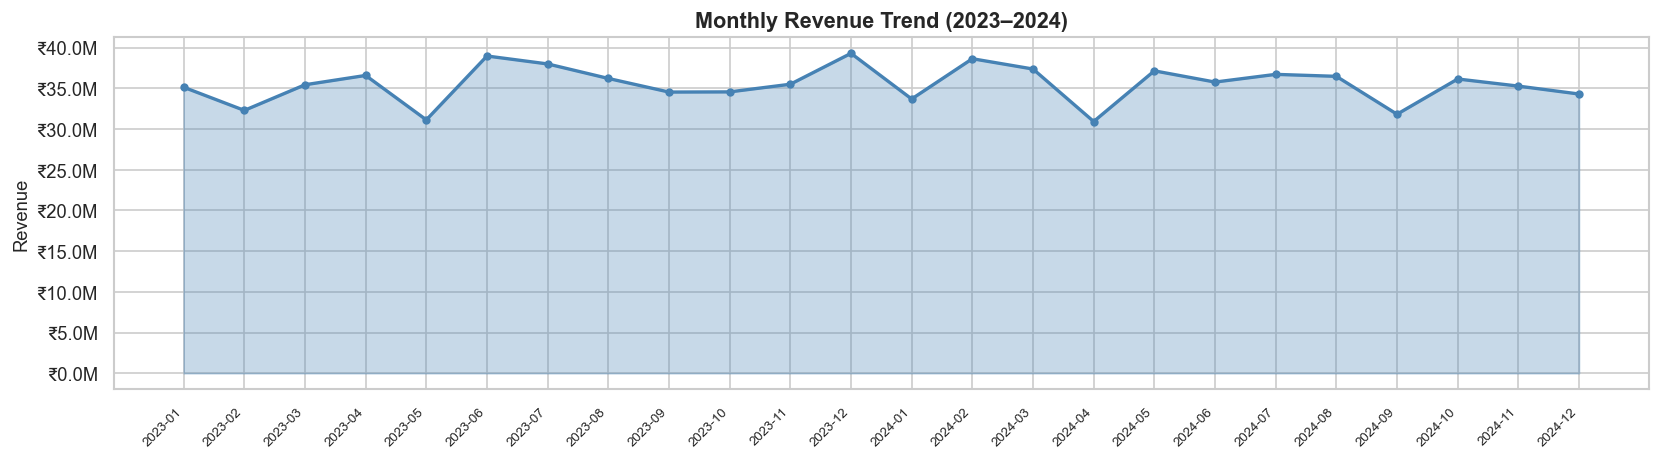

In [14]:
# --- Monthly Revenue Trend ---
monthly_rev = df[df['order_status'].isin(['Delivered','Pending'])].groupby('year_month')['revenue'].sum().reset_index()
monthly_rev['year_month_dt'] = pd.to_datetime(monthly_rev['year_month'])
monthly_rev = monthly_rev.sort_values('year_month_dt')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(monthly_rev)), monthly_rev['revenue'], alpha=0.3, color='steelblue')
ax.plot(range(len(monthly_rev)), monthly_rev['revenue'], color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_xticks(range(len(monthly_rev)))
ax.set_xticklabels(monthly_rev['year_month'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_title('Monthly Revenue Trend (2023–2024)', fontweight='bold')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()

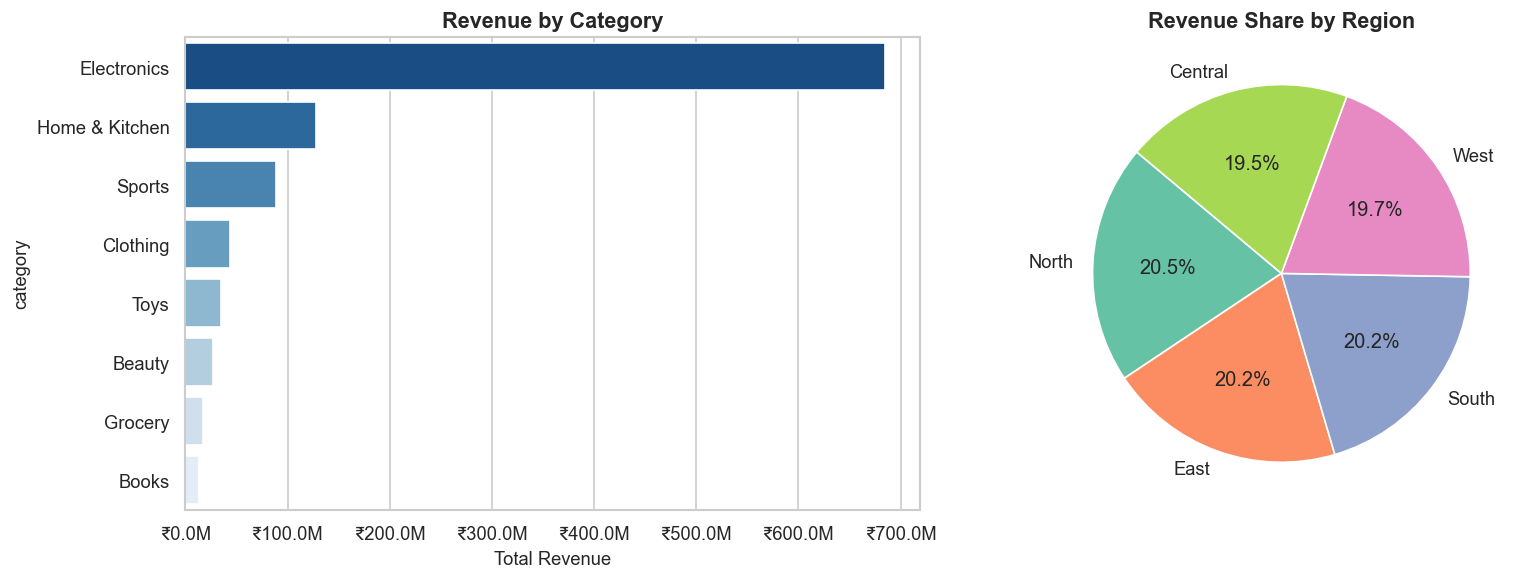

In [15]:
# --- Revenue by Category & Region ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, palette='Blues_r', ax=axes[0])
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].set_xlabel('Total Revenue')

reg_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
colors = sns.color_palette('Set2', len(reg_rev))
axes[1].pie(reg_rev.values, labels=reg_rev.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Revenue Share by Region', fontweight='bold')

plt.tight_layout()
plt.show()

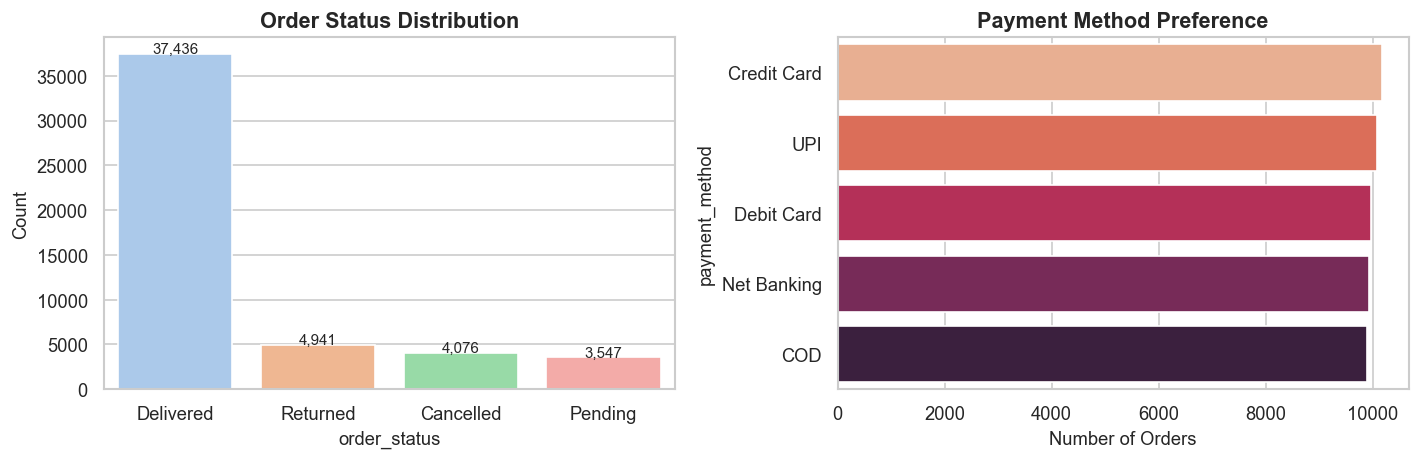

In [16]:
# --- Order Status Distribution & Payment Methods ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

status_counts = df['order_status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, palette='pastel', ax=axes[0])
axes[0].set_title('Order Status Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+100), ha='center', fontsize=9)

pay_counts = df['payment_method'].value_counts()
sns.barplot(x=pay_counts.values, y=pay_counts.index, palette='rocket_r', ax=axes[1])
axes[1].set_title('Payment Method Preference', fontweight='bold')
axes[1].set_xlabel('Number of Orders')

plt.tight_layout()
plt.show()

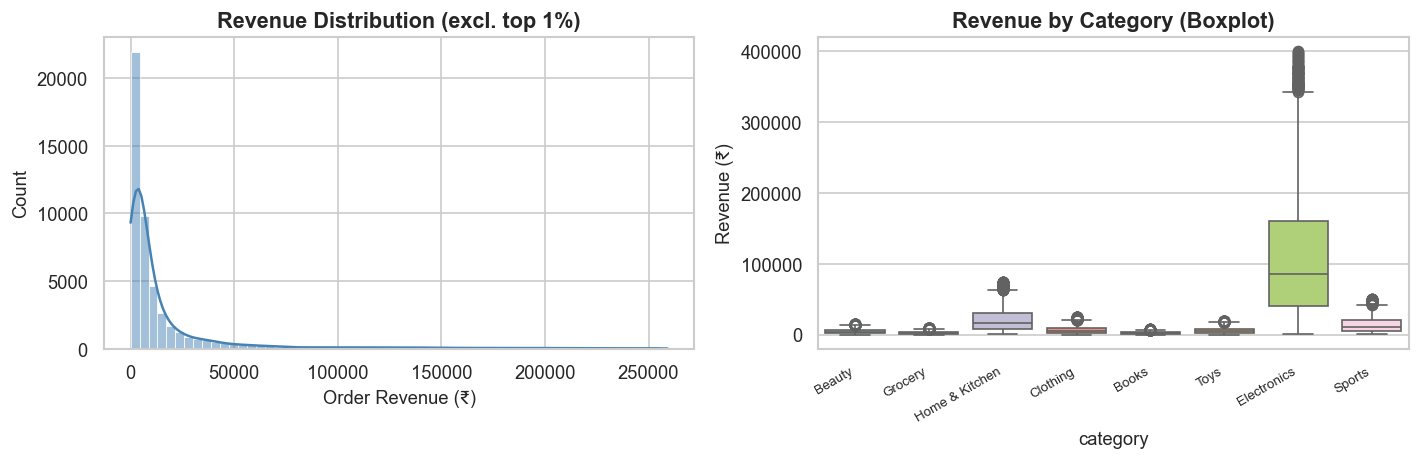

In [17]:
# --- Revenue Distribution & Outliers ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df['revenue'] < df['revenue'].quantile(0.99)]['revenue'], bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Revenue Distribution (excl. top 1%)', fontweight='bold')
axes[0].set_xlabel('Order Revenue (₹)')

sns.boxplot(data=df, x='category', y='revenue', palette='Set3', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[1].set_title('Revenue by Category (Boxplot)', fontweight='bold')
axes[1].set_ylabel('Revenue (₹)')

plt.tight_layout()
plt.show()

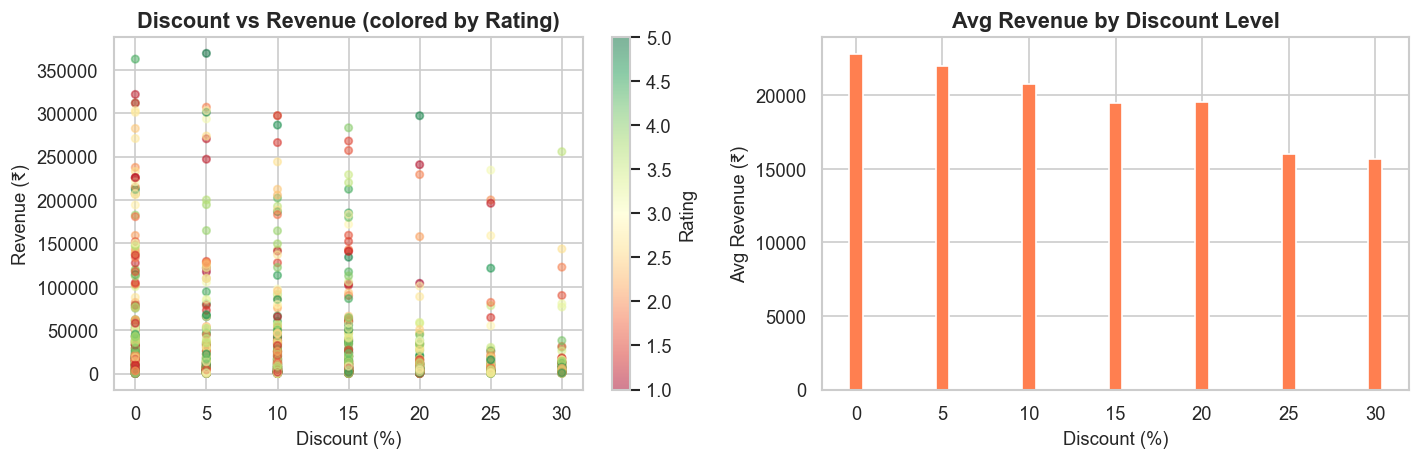

In [18]:
# --- Discount vs Revenue Scatter ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample = df.sample(2000, random_state=42)
scatter = axes[0].scatter(sample['discount_pct'], sample['revenue'], c=sample['rating'], cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[0], label='Rating')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Revenue (₹)')
axes[0].set_title('Discount vs Revenue (colored by Rating)', fontweight='bold')

avg_disc_rev = df.groupby('discount_pct')['revenue'].mean()
axes[1].bar(avg_disc_rev.index, avg_disc_rev.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel('Avg Revenue (₹)')
axes[1].set_title('Avg Revenue by Discount Level', fontweight='bold')

plt.tight_layout()
plt.show()

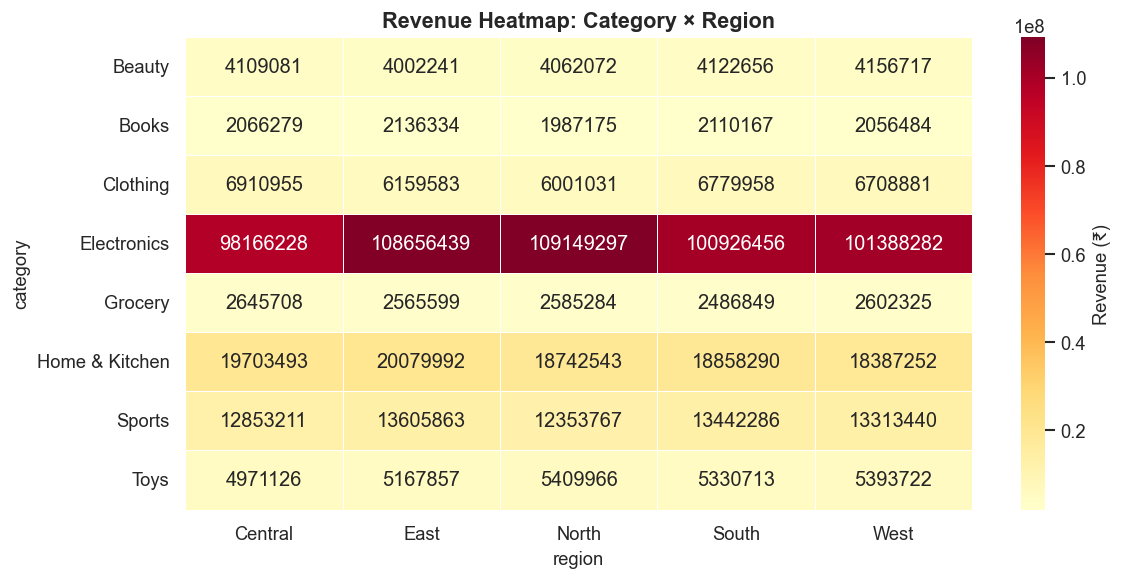

In [19]:
# --- Heatmap: Category x Region Revenue ---
pivot = df[df['order_status']=='Delivered'].pivot_table(
    values='revenue', index='category', columns='region', aggfunc='sum'
).round(0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Revenue (₹)'}, ax=ax)
ax.set_title('Revenue Heatmap: Category × Region', fontweight='bold')
plt.tight_layout()
plt.show()

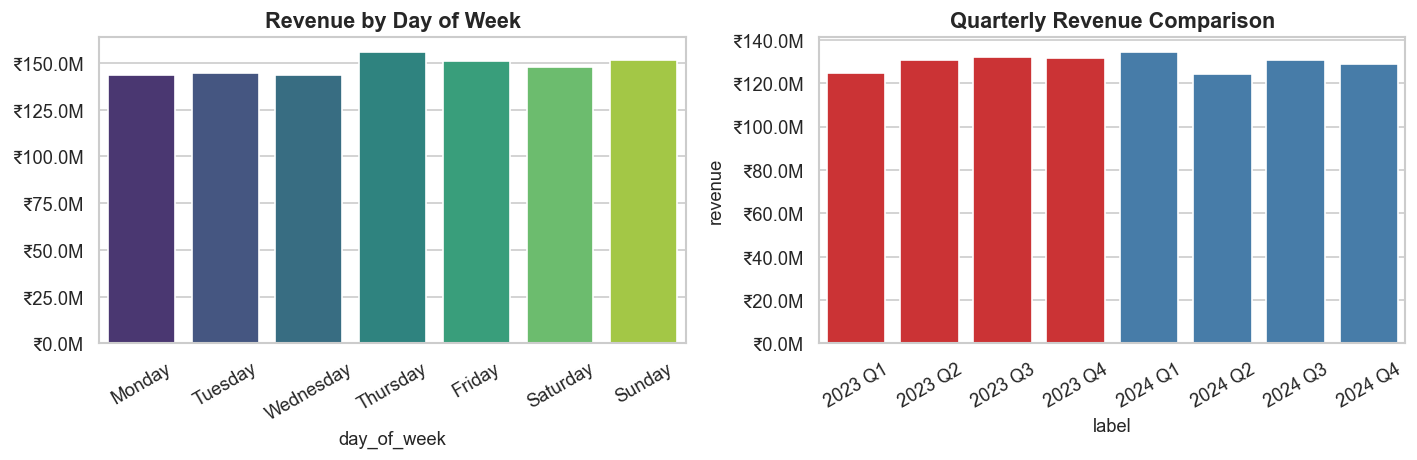

In [20]:
# --- Day of Week & Quarterly Trends ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = df.groupby('day_of_week')['revenue'].sum().reindex(dow_order)
sns.barplot(x=dow_rev.index, y=dow_rev.values, palette='viridis', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
axes[0].set_title('Revenue by Day of Week', fontweight='bold')

qtr_rev = df.groupby(['year','quarter'])['revenue'].sum().reset_index()
qtr_rev['label'] = qtr_rev['year'].astype(str) + ' Q' + qtr_rev['quarter'].astype(str)
sns.barplot(data=qtr_rev, x='label', y='revenue', hue='year', palette='Set1', ax=axes[1], legend=False)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
axes[1].set_title('Quarterly Revenue Comparison', fontweight='bold')

plt.tight_layout()
plt.show()

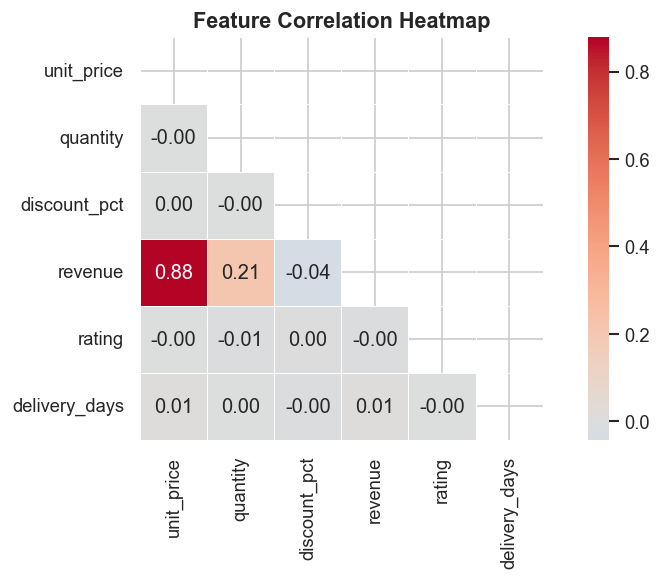

In [21]:
# --- Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(8, 5))
corr = df[['unit_price','quantity','discount_pct','revenue','rating','delivery_days']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

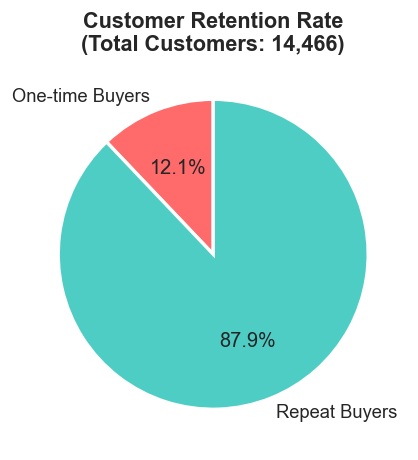

Retention Rate: 87.9%


In [22]:
# --- Customer Retention Pie ---
cust_order_counts = df.groupby('customer_id')['order_id'].nunique()
one_time = (cust_order_counts == 1).sum()
repeat   = (cust_order_counts  > 1).sum()

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([one_time, repeat], labels=['One-time Buyers', 'Repeat Buyers'],
       autopct='%1.1f%%', colors=['#FF6B6B','#4ECDC4'], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title(f'Customer Retention Rate\n(Total Customers: {one_time+repeat:,})', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Retention Rate: {repeat/(one_time+repeat)*100:.1f}%')

## 6. Key Insights Summary

In [27]:
total_rev    = df[df['order_status']=='Delivered']['revenue'].sum()
aov          = df[df['order_status']=='Delivered']['revenue'].mean()
top_cat      = df.groupby('category')['revenue'].sum().idxmax()
top_region   = df.groupby('region')['revenue'].sum().idxmax()
return_rate  = (df['order_status']=='Returned').mean()*100
retention    = repeat/(one_time+repeat)*100

print('=' * 50)
print('       KEY BUSINESS INSIGHTS')
print('=' * 50)
print(f'  Total Delivered Revenue : ₹{total_rev:,.0f}')
print(f'   Average Order Value     : ₹{aov:,.2f}')
print(f'   Top Category            : {top_cat}')
print(f'   Top Region              : {top_region}')
print(f'   Return Rate             : {return_rate:.1f}%')
print(f'   Customer Retention Rate : {retention:.1f}%')
print('=' * 50)

       KEY BUSINESS INSIGHTS
  Total Delivered Revenue : ₹782,155,601
   Average Order Value     : ₹20,893.14
   Top Category            : Electronics
   Top Region              : North
   Return Rate             : 9.9%
   Customer Retention Rate : 87.9%
